In [1]:
import os
import sys
import math
import json
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/Impact of Lifestyle Factors on Student Productivity (Responses).csv")

--- INSIGHT 1: Sleep Hours vs Productivity ---
Productivity_Class                                   Decreased  Increased  \
Q6. On average, how many hours do you sleep per...                          
Less than 5 hours                                   100.000000   0.000000   
5–6 hours                                            56.756757   0.000000   
6–7 hours                                            33.928571  16.071429   
7–8 hours                                            31.818182  18.181818   
More than 8 hours                                    71.428571  14.285714   

Productivity_Class                                  No impact  
Q6. On average, how many hours do you sleep per...             
Less than 5 hours                                    0.000000  
5–6 hours                                           43.243243  
6–7 hours                                           50.000000  
7–8 hours                                           50.000000  
More than 8 hours            

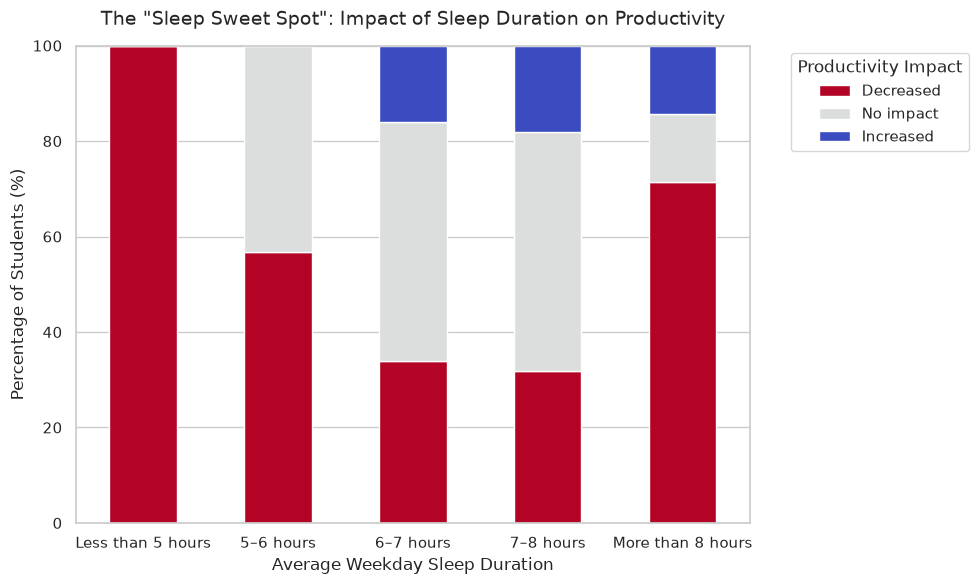

In [4]:


# Set visual style
sns.set_theme(style="whitegrid")


target_col = 'Q31. How would you rate your overall academic productivity on a typical day?'
df = df.dropna(subset=[target_col])

# Map target to 3 clear classes
def map_target(val):
    if val in [1.0, 2.0]: return 'Decreased'
    elif val == 3.0: return 'No impact'
    elif val in [4.0, 5.0]: return 'Increased'
    return 'No impact'

df['Productivity_Class'] = df[target_col].apply(map_target)

# Define exact column names for easy access
col_sleep = 'Q6. On average, how many hours do you sleep per night on weekdays?'
col_phone_bed = 'Q23. Do you use your phone for 30+ minutes immediately before going to sleep?'
col_fatigue = 'Q8. How often do you feel sleepy or tired during classes or study sessions?'


# ---------------------------------------------------------
# Insight 1: The "Sleep Sweet Spot"
# ---------------------------------------------------------
print("--- INSIGHT 1: Sleep Hours vs Productivity ---")
sleep_order = ['Less than 5 hours', '5–6 hours', '6–7 hours', '7–8 hours', 'More than 8 hours']

# Calculate percentages
sleep_cross = pd.crosstab(df[col_sleep], df['Productivity_Class'], normalize='index') * 100
sleep_cross = sleep_cross.reindex(sleep_order)
print(sleep_cross)

# Plotting the Sleep Sweet Spot (Stacked Bar Chart)
ax = sleep_cross[['Decreased', 'No impact', 'Increased']].plot(
    kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm_r'
)
plt.title('The "Sleep Sweet Spot": Impact of Sleep Duration on Productivity', fontsize=14, pad=15)
plt.xlabel('Average Weekday Sleep Duration', fontsize=12)
plt.ylabel('Percentage of Students (%)', fontsize=12)
plt.legend(title='Productivity Impact', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()




--- INSIGHT 2: Bedtime Screen Time vs Daytime Fatigue ---
Q8. How often do you feel sleepy or tired during classes or study sessions?      Never  \
Q23. Do you use your phone for 30+ minutes imme...                                       
No                                                                            0.000000   
Rarely                                                                        8.333333   
Yes, but briefly (under 15 min)                                              12.000000   
Yes, always                                                                  11.904762   

Q8. How often do you feel sleepy or tired during classes or study sessions?  Rarely (1–2 times/week)  \
Q23. Do you use your phone for 30+ minutes imme...                                                     
No                                                                                         75.000000   
Rarely                                                                                  

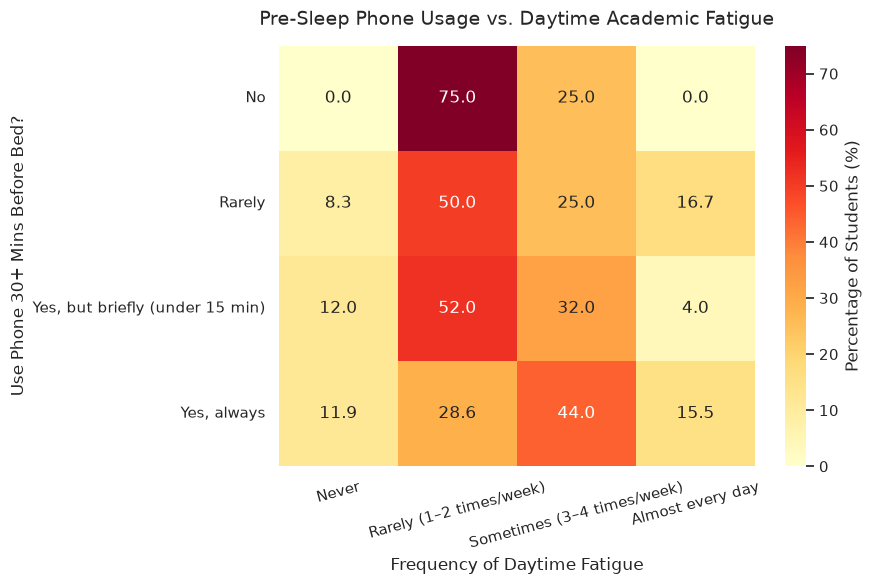

In [5]:

# ---------------------------------------------------------
# Insight 2: Pre-Sleep Screen Time vs. Daytime Fatigue
# ---------------------------------------------------------
print("\n--- INSIGHT 2: Bedtime Screen Time vs Daytime Fatigue ---")
phone_order = ['No', 'Rarely', 'Yes, but briefly (under 15 min)', 'Yes, always']
fatigue_order = ['Never', 'Rarely (1–2 times/week)', 'Sometimes (3–4 times/week)', 'Almost every day']

# Calculate cross-tabulation
screen_fatigue = pd.crosstab(df[col_phone_bed], df[col_fatigue], normalize='index') * 100
screen_fatigue = screen_fatigue.reindex(phone_order)[fatigue_order] # Reorder rows and columns logically
print(screen_fatigue)

# Plotting Screen Time vs Fatigue (Heatmap)
plt.figure(figsize=(9, 6))
sns.heatmap(screen_fatigue, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Percentage of Students (%)'})
plt.title('Pre-Sleep Phone Usage vs. Daytime Academic Fatigue', fontsize=14, pad=15)
plt.xlabel('Frequency of Daytime Fatigue', fontsize=12)
plt.ylabel('Use Phone 30+ Mins Before Bed?', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()





--- INSIGHT 3: Junk Food vs Productivity ---
Productivity_Class                                  Decreased  Increased  \
Q17. How often do you consume fast food or proc...                         
Rarely or never                                     44.827586  13.793103   
1–2 times per week                                  39.344262   9.836066   
3–4 times per week                                  37.500000  18.750000   
Almost daily                                        63.157895   5.263158   

Productivity_Class                                  No impact  
Q17. How often do you consume fast food or proc...             
Rarely or never                                     41.379310  
1–2 times per week                                  50.819672  
3–4 times per week                                  43.750000  
Almost daily                                        31.578947  


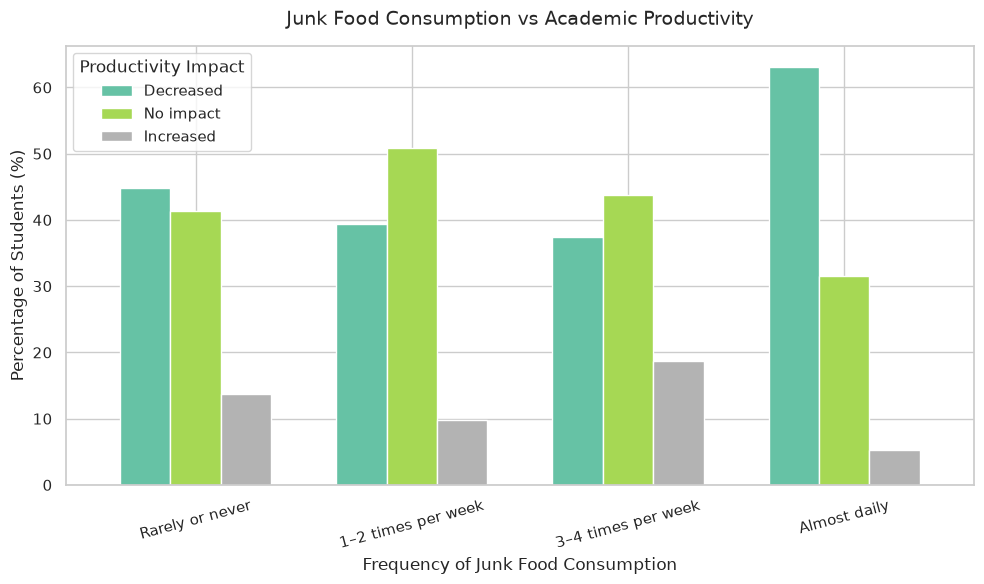

In [6]:
# ---------------------------------------------------------
# Insight 3: Junk Food Consumption vs Productivity
# ---------------------------------------------------------
print("\n--- INSIGHT 3: Junk Food vs Productivity ---")
col_junk = 'Q17. How often do you consume fast food or processed junk food?'
junk_order = ['Rarely or never', '1–2 times per week', '3–4 times per week', 'Almost daily']

# Calculate percentages
junk_cross = pd.crosstab(df[col_junk], df['Productivity_Class'], normalize='index') * 100
junk_cross = junk_cross.reindex(junk_order)
print(junk_cross)

# Plotting Junk Food vs Productivity (Grouped Bar Chart)
junk_cross[['Decreased', 'No impact', 'Increased']].plot(
    kind='bar', figsize=(10, 6), colormap='Set2', width=0.7
)
plt.title('Junk Food Consumption vs Academic Productivity', fontsize=14, pad=15)
plt.xlabel('Frequency of Junk Food Consumption', fontsize=12)
plt.ylabel('Percentage of Students (%)', fontsize=12)
plt.legend(title='Productivity Impact')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()